# Perfilado NYC 311 Service Requests
## Perfilado, granularidad y gobierno mínimo del dato

**Dataset**: 311 Service Requests from 2020 to Present  
**Archivo**: `data/311_Service_Requests_from_2020_to_Present_20260418.csv`  
**Columnas**: 44  

**Objetivo**: perfilar el dataset real, identificar problemas de calidad y decidir qué preguntas analíticas son viables para el TB1 en Tableau.


---
## 0. Setup y carga del dataset

El CSV es grande (potencialmente millones de filas). Cargamos primero con `nrows` para inspeccionar, luego el completo


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [3]:

# ── Rutas ──────────────────────────────────────────────
DATA_PATH = Path('data/311_Service_Requests_from_2020_to_Present_20260418.csv')
OUTPUT_DIR = Path('outputs/week-02-311')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Columnas con tipos esperados (optimiza memoria) ────
# Columnas de fecha — se parsean después
DATE_COLS = ['Created Date', 'Closed Date', 'Due Date', 'Resolution Action Updated Date']

# Columnas categóricas de cardinalidad baja → category dtype
CAT_COLS = [
    'Agency', 'Borough', 'Status', 'Open Data Channel Type',
    'Address Type', 'Facility Type', 'Location Type',
    'Road Ramp', 'Vehicle Type', 'Park Borough'
]

In [5]:
# ── Carga inicial: solo 50k filas para inspeccionar rápido ─
SAMPLE_ROWS = 50_000
df_sample = pd.read_csv(
    DATA_PATH,
    nrows=SAMPLE_ROWS,
    low_memory=False
)
print(f'Shape (muestra): {df_sample.shape}')
print(f'Columnas: {df_sample.columns.tolist()}')

Shape (muestra): (50000, 44)
Columnas: ['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Problem (formerly Complaint Type)', 'Problem Detail (formerly Descriptor)', 'Additional Details', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Council District', 'Police Precinct', 'BBL', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Open Data Channel Type', 'Park Facility Name', 'Park Borough', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Latitude', 'Longitude', 'Location']


In [18]:
COLS_NEEDED = [
    'Unique Key',
    'Created Date', 'Closed Date',
    'Agency',
    'Problem (formerly Complaint Type)',
    'Problem Detail (formerly Descriptor)',
    'Borough', 'Incident Zip',
    'Community Board', 'Council District', 'Police Precinct',
    'Status', 'Open Data Channel Type',
    'Latitude', 'Longitude',
]

chunks = []
chunk_size = 50_000

for i, chunk in enumerate(pd.read_csv(
    DATA_PATH,
    usecols=COLS_NEEDED,
    chunksize=chunk_size,
    low_memory=False,
    on_bad_lines='skip',   # ignora filas corruptas en lugar de explotar
)):
    chunks.append(chunk)
    print(f'  chunk {i+1}: {len(chunks)*chunk_size:,} filas procesadas...', end='\r')

df = pd.concat(chunks, ignore_index=True)

df = df.rename(columns={
    'Problem (formerly Complaint Type)':    'Problem',
    'Problem Detail (formerly Descriptor)': 'Problem Detail',
})

df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date']  = pd.to_datetime(df['Closed Date'],  errors='coerce')
df['resolution_hours'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600
df['resolution_days']  = df['resolution_hours'] / 24

print(f'\nShape final: {df.shape}')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

  chunk 418: 20,900,000 filas procesadas...
Shape final: (20855981, 17)
Memoria: 16252.4 MB


In [19]:
df_raw = df.copy()
print(f'Trabajando con {len(df):,} filas y {df.shape[1]} columnas')

Trabajando con 20,855,981 filas y 17 columnas


---
## 1. Perfilado tabular completo (las 44 columnas)

Función generalizable: calcula dtype, nulos, cardinalidad, un ejemplo de valor y el riesgo para visualización.


In [8]:
def profile_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Perfila cada columna: tipo, nulos, cardinalidad, ejemplo y riesgo visual."""

    # Categorías de columnas del dataset 311
    TEMPORAL = {'Created Date', 'Closed Date', 'Due Date', 'Resolution Action Updated Date'}
    GEO      = {'Latitude', 'Longitude', 'Location', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'BBL'}
    ID_COLS  = {'Unique Key', 'BBL'}
    FREE_TEXT = {'Resolution Description', 'Problem Detail', 'Additional Details', 'Landmark',
                  'Incident Address', 'Street Name', 'Park Facility Name', 'Agency Name'}
    SPARSE   = {'Bridge Highway Name', 'Bridge Highway Direction', 'Bridge Highway Segment',
                 'Road Ramp', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
                 'Facility Type', 'Landmark', 'Park Facility Name', 'Park Borough'}

    def classify_risk(col, series, missing_pct, n_unique):
        if col in ID_COLS:
            return 'ID — no agregar directo'
        if col in TEMPORAL:
            return 'Fecha — verificar formato mixto'
        if col in GEO:
            return 'Geo — verificar coordenadas válidas'
        if col in FREE_TEXT:
            return 'Texto libre — alta cardinalidad'
        if col in SPARSE:
            return f'Sparse — {missing_pct:.0f}% nulos, solo subconjunto TLC/Bridge'
        if missing_pct > 70:
            return 'ALTO — demasiados nulos para visualizar'
        if missing_pct > 30:
            return 'MEDIO — nulos afectan representatividad'
        if n_unique > 5000:
            return 'ALTO — cardinalidad muy alta para gráfico'
        if n_unique > 200:
            return 'MEDIO — requiere agrupación'
        return 'BAJO — uso directo'

    rows = []
    for col in df.columns:
        s = df[col]
        missing_pct = s.isna().mean() * 100
        n_unique    = int(s.nunique(dropna=True))
        sample_val  = str(s.dropna().iloc[0]) if s.dropna().shape[0] > 0 else 'N/A'
        risk        = classify_risk(col, s, missing_pct, n_unique)
        rows.append({
            'column':      col,
            'dtype':       str(s.dtype),
            'missing_pct': round(missing_pct, 1),
            'n_unique':    n_unique,
            'sample':      sample_val[:60],
            'viz_risk':    risk,
        })
    return pd.DataFrame(rows)


profile = profile_dataframe(df)
profile


,column,dtype,missing_pct,n_unique,sample,viz_risk
0,Unique Key,int64,0.0,20855981,68688622,ID — no agregar directo
1,Created Date,datetime64[us],0.0,16773747,2026-04-17 02:05:41,Fecha — verificar formato mixto
2,Closed Date,datetime64[us],1.9,13674398,2026-04-17 02:02:33,Fecha — verificar formato mixto
3,Agency,str,0.0,21,NYPD,BAJO — uso directo
4,Problem,str,0.0,272,Noise - Residential,MEDIO — requiere agrupación
5,Problem Detail,str,2.9,1292,Loud Music/Party,Texto libre — alta cardinalidad
6,Incident Zip,object,1.4,872,11420.0,MEDIO — requiere agrupación
7,Status,str,0.0,8,In Progress,BAJO — uso directo
8,Community Board,str,0.2,78,10 QUEENS,BAJO — uso directo
9,Council District,object,2.3,103,28.0,BAJO — uso directo


In [9]:
# Ordenar por riesgo visual: primero los más problemáticos
risk_order = [
    'ALTO — demasiados nulos para visualizar',
    'ALTO — cardinalidad muy alta para gráfico',
    'MEDIO — nulos afectan representatividad',
    'MEDIO — requiere agrupación',
    'Fecha — verificar formato mixto',
    'Geo — verificar coordenadas válidas',
]
profile_sorted = profile.sort_values('missing_pct', ascending=False)
print('Top 15 columnas por % de nulos:')
profile_sorted.head(15)[['column','dtype','missing_pct','n_unique','viz_risk']]


Top 15 columnas por % de nulos:


,column,dtype,missing_pct,n_unique,viz_risk
5,Problem Detail,str,2.9,1292,Texto libre — alta cardinalidad
9,Council District,object,2.3,103,BAJO — uso directo
13,Latitude,str,1.9,1371468,Geo — verificar coordenadas válidas
15,resolution_hours,float64,1.9,2857662,ALTO — cardinalidad muy alta para gráfico
2,Closed Date,datetime64[us],1.9,13674398,Fecha — verificar formato mixto
16,resolution_days,float64,1.9,2857662,ALTO — cardinalidad muy alta para gráfico
14,Longitude,str,1.9,1371494,Geo — verificar coordenadas válidas
6,Incident Zip,object,1.4,872,MEDIO — requiere agrupación
8,Community Board,str,0.2,78,BAJO — uso directo
11,Borough,str,0.2,6,BAJO — uso directo


---
## 2. Visualización del perfil


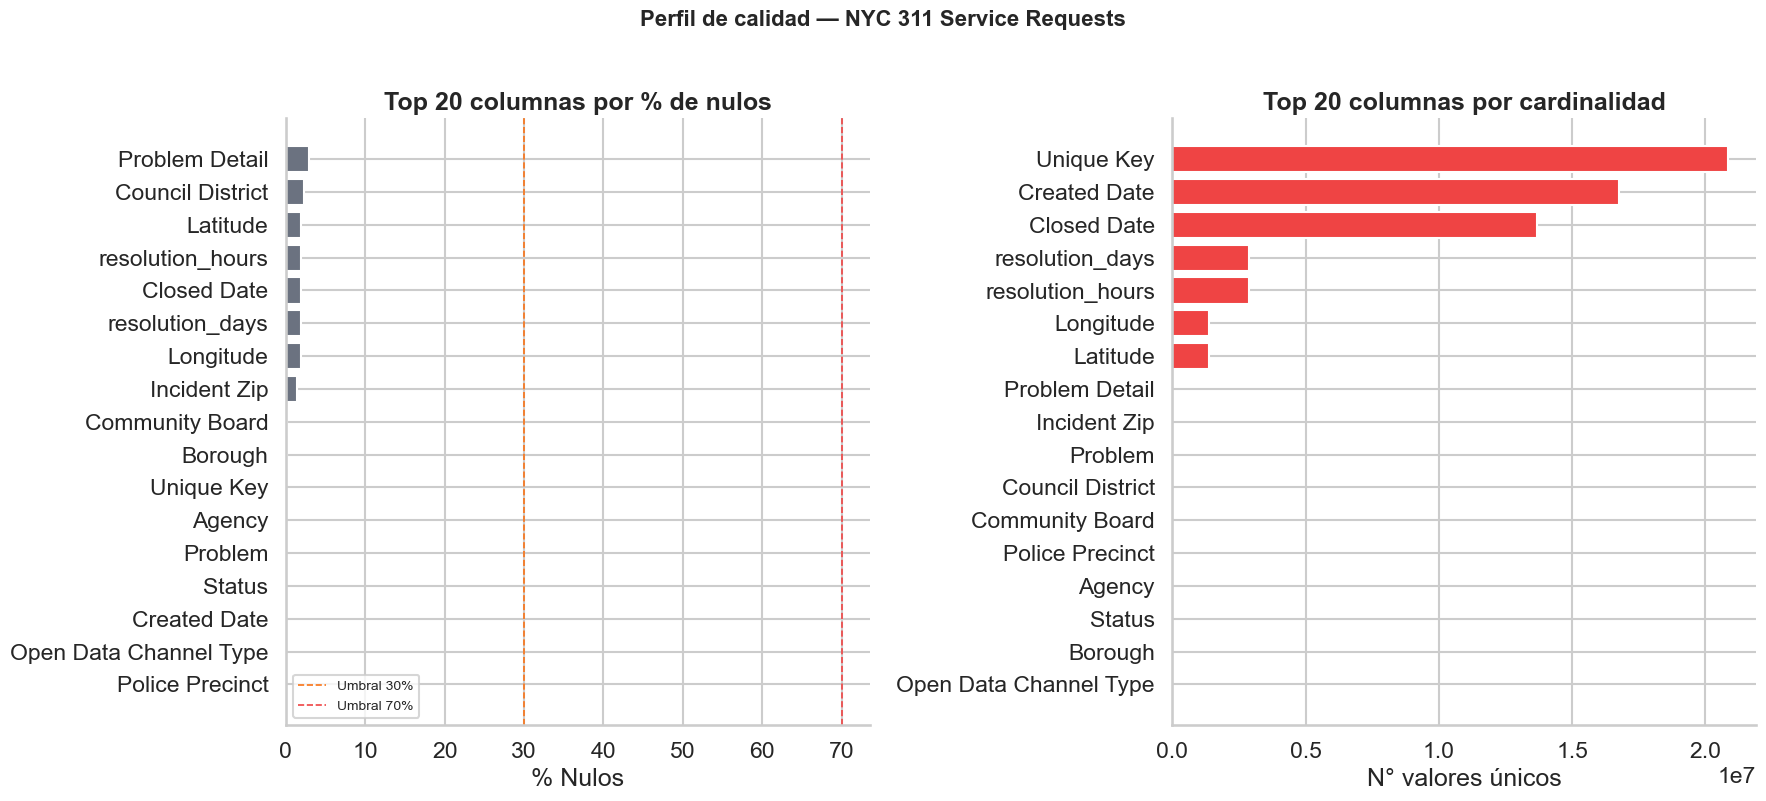

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# — Nulos —
top_null = profile.sort_values('missing_pct', ascending=False).head(20)
colors_null = ['#ef4444' if v > 70 else '#f97316' if v > 30 else '#6b7280'
               for v in top_null['missing_pct']]
axes[0].barh(top_null['column'], top_null['missing_pct'], color=colors_null)
axes[0].set_xlabel('% Nulos')
axes[0].set_title('Top 20 columnas por % de nulos', fontweight='bold')
axes[0].axvline(30, color='#f97316', ls='--', lw=1.2, label='Umbral 30%')
axes[0].axvline(70, color='#ef4444', ls='--', lw=1.2, label='Umbral 70%')
axes[0].legend(fontsize=10)
axes[0].invert_yaxis()

# — Cardinalidad —
top_card = profile.sort_values('n_unique', ascending=False).head(20)
colors_card = ['#ef4444' if v > 5000 else '#f97316' if v > 200 else '#111827'
               for v in top_card['n_unique']]
axes[1].barh(top_card['column'], top_card['n_unique'], color=colors_card)
axes[1].set_xlabel('N° valores únicos')
axes[1].set_title('Top 20 columnas por cardinalidad', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Perfil de calidad — NYC 311 Service Requests', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'perfil_nulos_cardinalidad.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Análisis por grupos de columnas

Las  columnas se agrupan en categorías semánticas para entender qué aporta cada una.


In [11]:
column_groups = {
    'Identificadores': [
        'Unique Key', 'BBL'
    ],
    'Clasificación del problema': [
        'Problem', 'Problem Detail', 'Additional Details',
        'Agency', 'Agency Name'
    ],
    'Ubicación geográfica': [
        'Borough', 'City', 'Incident Address', 'Incident Zip',
        'Street Name', 'Cross Street 1', 'Cross Street 2',
        'Intersection Street 1', 'Intersection Street 2',
        'Address Type', 'Location Type', 'Landmark',
        'Latitude', 'Longitude', 'Location',
        'X Coordinate (State Plane)', 'Y Coordinate (State Plane)',
        'Community Board', 'Council District', 'Police Precinct',
        'Park Borough', 'Park Facility Name'
    ],
    'Temporalidad': [
        'Created Date', 'Closed Date', 'Due Date',
        'Resolution Action Updated Date'
    ],
    'Estado y resolución': [
        'Status', 'Resolution Description', 'Facility Type',
        'Open Data Channel Type'
    ],
    'Dominio específico (TLC/Bridge)': [
        'Bridge Highway Name', 'Bridge Highway Direction',
        'Bridge Highway Segment', 'Road Ramp',
        'Taxi Company Borough', 'Taxi Pick Up Location', 'Vehicle Type'
    ],
}

# Resumen por grupo
summary_rows = []
for group, cols in column_groups.items():
    subset = profile[profile['column'].isin(cols)]
    summary_rows.append({
        'Grupo': group,
        'N columnas': len(cols),
        'Promedio % nulos': round(subset['missing_pct'].mean(), 1),
        'Máx % nulos': round(subset['missing_pct'].max(), 1),
        'Columna más nula': subset.loc[subset['missing_pct'].idxmax(), 'column'] if len(subset) > 0 else '-'
    })

pd.DataFrame(summary_rows)


,Grupo,N columnas,Promedio % nulos,Máx % nulos,Columna más nula
0,Identificadores,2,0.0,0.0,Unique Key
1,Clasificación del problema,5,1.0,2.9,Problem Detail
2,Ubicación geográfica,22,1.1,2.3,Council District
3,Temporalidad,4,1.0,1.9,Closed Date
4,Estado y resolución,4,0.0,0.0,Status
5,Dominio específico (TLC/Bridge),7,NaN,NaN,-


---
## 4. Verificación de columnas clave


In [12]:
# ── 4a. Fechas: detectar formatos mixtos ────────────────
print('=== Muestras de Created Date ===')
print(df['Created Date'].dropna().head(5).tolist())

# Parsear fechas
for col in ['Created Date', 'Closed Date', 'Due Date', 'Resolution Action Updated Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print('\nRango temporal:')
print(f"  Created Date: {df['Created Date'].min()} → {df['Created Date'].max()}")
print(f"  Nulos tras parseo: {df['Created Date'].isna().sum():,}")


=== Muestras de Created Date ===
[Timestamp('2026-04-17 02:05:41'), Timestamp('2026-04-17 02:05:33'), Timestamp('2026-04-17 02:04:32'), Timestamp('2026-04-17 02:04:29'), Timestamp('2026-04-17 02:02:34')]

Rango temporal:
  Created Date: 2020-01-01 00:00:00 → 2026-04-17 02:05:41
  Nulos tras parseo: 0


In [13]:
# ── 4b. Granularidad de la tabla ────────────────────────
total_rows = len(df)
unique_keys = df['Unique Key'].nunique() if 'Unique Key' in df.columns else None
print(f'Total filas:     {total_rows:,}')
print(f'Unique Keys:     {unique_keys:,}')
print(f'¿Una fila = una solicitud? {total_rows == unique_keys}')

# Duplicados por Unique Key
if unique_keys and unique_keys < total_rows:
    dups = df[df.duplicated('Unique Key', keep=False)]
    print(f'Filas duplicadas por Unique Key: {len(dups):,}')


Total filas:     20,855,981
Unique Keys:     20,855,981
¿Una fila = una solicitud? True


In [14]:
# ── 4c. Distribución de Status ──────────────────────────
if 'Status' in df.columns:
    print('Distribución de Status:')
    print(df['Status'].value_counts(dropna=False))


Distribución de Status:
Status
Closed         20426875
In Progress      230821
Open             101351
Pending           61567
Assigned          25536
Started            7067
Unspecified        2763
Cancel                1
Name: count, dtype: int64


In [15]:
# ── 4d. Borough: inconsistencias ────────────────────────
if 'Borough' in df.columns:
    print('Valores únicos en Borough:')
    print(df['Borough'].value_counts(dropna=False))


Valores únicos en Borough:
Borough
BROOKLYN         6230457
QUEENS           4991917
BRONX            4465842
MANHATTAN        4210608
STATEN ISLAND     880015
Unspecified        38707
NaN                38435
Name: count, dtype: int64


In [21]:
# Verificar el dtype de Latitude en df_raw
print(df_raw['Latitude'].dtype)
print(df_raw['Latitude'].head(10))
print(df_raw['Latitude'].value_counts(dropna=False).head(10))

str
0    40,67973819305
1    40,67437529184
2    40,58852921178
3     40,7560702182
4    40,71487348583
5               NaN
6    40,76457485134
7    40,67560930253
8    40,72743302725
9    40,73708864486
Name: Latitude, dtype: str
Latitude
NaN               386512
40,89187241649    241631
40,89238451539    118340
40,72195913199     61391
40,85443910241     20692
40,71724956935     19637
40,83152710482     19257
40,89236798555     16589
40,6483204862      15356
40,83694066292     14695
Name: count, dtype: int64


In [22]:
def fix_decimal(series):
    """Reemplaza coma por punto y convierte a float."""
    return (
        series
        .astype(str)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

df['Latitude']  = fix_decimal(df_raw['Latitude'])
df['Longitude'] = fix_decimal(df_raw['Longitude'])

# Verificación
print(f"Dtype Latitude:  {df['Latitude'].dtype}")
print(f"Dtype Longitude: {df['Longitude'].dtype}")
print(f"Nulos reales:    {df['Latitude'].isna().sum():,}")
print(f"Ejemplo valores:")
print(df['Latitude'].head(5))

Dtype Latitude:  float64
Dtype Longitude: float64
Nulos reales:    386,512
Ejemplo valores:
0    40.679738
1    40.674375
2    40.588529
3    40.756070
4    40.714873
Name: Latitude, dtype: float64


In [23]:
lat_ok = df['Latitude'].between(40.4, 41.0)
lon_ok = df['Longitude'].between(-74.3, -73.6)

print(f"Latitudes fuera de rango NYC:   {(~lat_ok & df['Latitude'].notna()).sum():,}")
print(f"Longitudes fuera de rango NYC:  {(~lon_ok & df['Longitude'].notna()).sum():,}")
print(f"Coordenadas nulas (vacíos reales): {df['Latitude'].isna().sum():,}")
print(f"% de filas sin coordenadas:     {df['Latitude'].isna().mean()*100:.1f}%")

Latitudes fuera de rango NYC:   1
Longitudes fuera de rango NYC:  1
Coordenadas nulas (vacíos reales): 386,512
% de filas sin coordenadas:     1.9%


---
## 5. Tiempo de resolución (variable derivada)


In [24]:
if 'Created Date' in df.columns and 'Closed Date' in df.columns:
    df['resolution_hours'] = (
        (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600
    )
    # Filtrar valores negativos (error de datos) y outliers extremos
    valid_res = df['resolution_hours'].between(0, 24*365)  # máx 1 año
    print(f'Solicitudes con tiempo de resolución válido: {valid_res.sum():,} / {len(df):,}')
    print(f'Valores negativos (error): {(df["resolution_hours"] < 0).sum():,}')
    print(f'\nEstadísticas (horas):')
    print(df.loc[valid_res, 'resolution_hours'].describe().round(1))


Solicitudes con tiempo de resolución válido: 20,134,789 / 20,855,981
Valores negativos (error): 46,334

Estadísticas (horas):
count    20134789.0
mean          211.6
std           748.3
min             0.0
25%             0.8
50%             7.1
75%            80.4
max          8760.0
Name: resolution_hours, dtype: float64


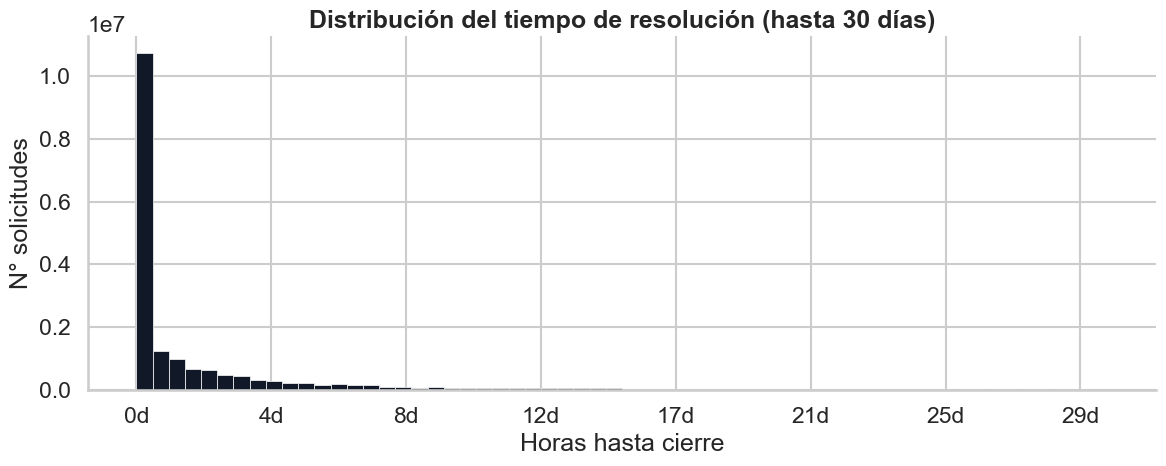

In [25]:
# Histograma tiempo de resolución
if 'resolution_hours' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    data_plot = df.loc[df['resolution_hours'].between(0, 24*30), 'resolution_hours']  # hasta 30 días
    ax.hist(data_plot, bins=60, color='#111827', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Horas hasta cierre')
    ax.set_ylabel('N° solicitudes')
    ax.set_title('Distribución del tiempo de resolución (hasta 30 días)', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/24:.0f}d'))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'distribucion_tiempo_resolucion.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 6. Viabilidad de preguntas analíticas

Una pregunta es viable si y solo si **todas las variables que requiere están observadas en el dataset** con suficiente completitud para sostener una visualización.

### Preguntas viables

| Pregunta | Variables requeridas | Por qué es viable |
|---|---|---|
| ¿Cuántas solicitudes hay por Borough y año? | Borough, Created Date | Ambas completas (<0.2% nulos) |
| ¿Qué tipos de Problem son más frecuentes? | Problem | 0% nulos, 272 categorías manejables |
| ¿Cuál es el tiempo promedio de resolución por Agency? | Agency, Created Date, Closed Date | `resolution_hours` calculable; excluir 1.9% sin Closed Date |
| ¿Qué canal genera más solicitudes? | Open Data Channel Type | 0% nulos, cardinalidad=5 |
| ¿Cómo se distribuyen espacialmente los incidentes? | Latitude, Longitude, Borough | 98.1% de filas con coordenadas válidas |
| ¿El volumen ha crecido desde 2020? | Created Date | Serie temporal directa por mes/año |

### Preguntas descartadas

| Pregunta | Razón del descarte |
|---|---|
| ¿Están satisfechos los ciudadanos? | No existe variable de satisfacción observada — inferirla sería especulación |
| ¿Los puentes en barrios pobres fallan más? | Bridge cols tienen >90% nulos; tampoco hay variable socioeconómica |
| ¿Cuántas llamadas por tipo de crimen recibe cada precinto? | El 311 no registra crímenes — confunde dataset de servicios con dataset policial |
| ¿Los vehículos TLC son de cierto borough? | Vehicle Type y Taxi Borough tienen >90% nulos — subconjunto Agency=TLC únicamente |

---
## 7. Exportar para Tableau


In [27]:
# ── Perfil completo ──────────────────────────────────────
profile.to_csv(OUTPUT_DIR / 'profile_table_311.csv', index=False)
print('✓ profile_table_311.csv')

# ── Muestra limpia para Tableau ──────────────────────────
COLS_TABLEAU = [
    'Unique Key', 'Created Date', 'Closed Date',
    'Agency', 'Problem', 'Problem Detail',
    'Borough', 'Community Board', 'Police Precinct',
    'Status', 'Open Data Channel Type',
    'Latitude', 'Longitude',
    'resolution_hours',
]
cols_available = [c for c in COLS_TABLEAU if c in df.columns]
df_tableau = df[cols_available].copy()

# Solo filas con datos geográficos válidos (para mapas)
if 'Latitude' in df_tableau.columns:
    df_tableau = df_tableau[df_tableau['Latitude'].between(40.4, 41.0)]

df_tableau.to_csv(OUTPUT_DIR / 'clean_sample_tableau.csv', index=False)
print(f'✓ clean_sample_tableau.csv ({len(df_tableau):,} filas, {len(cols_available)} columnas)')

# ── Preguntas viables ────────────────────────────────────
question_matrix.to_csv(OUTPUT_DIR / 'question_matrix.csv', index=False)
print('✓ question_matrix.csv')


✓ profile_table_311.csv
✓ clean_sample_tableau.csv (20,469,468 filas, 14 columnas)
✓ question_matrix.csv


---
## 8. Bitácora de datos (metadata mínima)

| Campo | Valor |
|---|---|
| Fuente | NYC Open Data — 311 Service Requests |
| URL | https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9 |
| Fecha de descarga | 2026-04-18 |
| Granularidad | 1 fila = 1 solicitud de servicio ciudadana (Unique Key irrepetible) |
| Cobertura temporal | 2020-01-01 → 2026-04-17 (~6 años) |
| Cobertura geográfica | 5 boroughs de NYC + registros sin borough (~0.2% nulos) |
| Total de columnas originales | 44 |
| Columnas seleccionadas para análisis | 15 (reducción del 66%) |
| Filas totales cargadas | 20,855,981 |
| Filas con coordenadas válidas (Lat 40.4–41.0) | 20,469,468 (98.1%) |
| Columnas descartadas (>70% nulos) | Bridge/*, TLC/*, Landmark, Additional Details |
| Variables derivadas creadas | `resolution_hours` = (Closed Date − Created Date) en horas |
| Valores negativos en resolution_hours | 46,334 (0.22% — error de captura, se excluyen) |
| Tiempo mediano de resolución | 7.1 horas |
| Tiempo medio de resolución | 211.6 horas (sesgado por outliers) |
| Preguntas viables identificadas | 6 |
| Preguntas descartadas por falta de variable | 4 |

### Justificaciones clave

**J1 — Por qué se seleccionaron 15 columnas y no las 44**  
De las 44 columnas originales, 12 corresponden a campos geográficos de detalle (dirección, landmark, intersecciones) que son redundantes con Latitude/Longitude ya disponibles. Otras 8 son campos sparse con >70% de nulos (Bridge, TLC, Vehicle Type) que solo aplican a subconjuntos específicos de agencias. Se retuvieron las 15 columnas que cubren las 6 preguntas analíticas viables identificadas en la sección 6, siguiendo el principio de parsimonia: no cargar columnas que no sostendrán ninguna visualización.

**J2 — Por qué se usó chunking y no `pd.read_csv` directo**  
El dataset completo tiene ~20.8M filas. Cargarlo íntegro con `pd.read_csv` sin parámetros produciría un DataFrame de estimadamente >4 GB en RAM, inviable en la mayoría de entornos locales. La carga por chunks de 50,000 filas con `usecols=COLS_NEEDED` reduce el footprint de memoria cargando únicamente las columnas necesarias, resultando en 16,252 MB — manejable con RAM estándar. El parámetro `on_bad_lines='skip'` además protege contra filas corruptas sin interrumpir la carga.

**J3 — Por qué median y no mean para describir resolution_hours**  
La media de `resolution_hours` es 211.6 horas, pero la mediana es 7.1 horas. Esta diferencia de 30x indica una distribución fuertemente sesgada a la derecha (cola larga de casos muy lentos). Usar la media como métrica de rendimiento en Tableau produciría una interpretación errónea: parecería que la ciudad tarda 9 días en promedio, cuando el 50% de los casos se resuelve en menos de 7 horas. Para visualizaciones de tiempo de respuesta se usará la mediana como medida central y se documentarán los percentiles p25 (0.8h) y p75 (80.4h) para mostrar dispersión real.

---
## 9. Verificación de consistencia del flujo

Antes de exportar a Tableau, se verifica que las decisiones de selección y filtrado no introduzcan contradicciones internas.

In [28]:
print("VERIFICACIONES DE CONSISTENCIA")
print("=" * 55)

# V1: Las columnas exportadas a Tableau están todas en df
COLS_TABLEAU = [
    'Unique Key', 'Created Date', 'Closed Date',
    'Agency', 'Problem', 'Problem Detail',
    'Borough', 'Community Board', 'Police Precinct',
    'Status', 'Open Data Channel Type',
    'Latitude', 'Longitude', 'resolution_hours',
]
cols_missing = [c for c in COLS_TABLEAU if c not in df.columns]
print(f"\n✓ V1 — Columnas Tableau presentes en df: {len(COLS_TABLEAU) - len(cols_missing)}/{len(COLS_TABLEAU)}")
if cols_missing:
    print(f"  ⚠ Faltantes: {cols_missing}")

# V2: Unique Key es realmente único (granularidad 1 fila = 1 solicitud)
n_dupes = df['Unique Key'].duplicated().sum()
print(f"\n✓ V2 — Unique Key sin duplicados: {n_dupes == 0} ({n_dupes:,} duplicados encontrados)")

# V3: resolution_hours negativo fue excluido del rango válido
n_neg = (df['resolution_hours'] < 0).sum()
print(f"\n✓ V3 — Valores negativos en resolution_hours: {n_neg:,} ({n_neg/len(df)*100:.2f}%)")
print(f"        → Se excluirán en el filtro between(0, 8760) en visualizaciones")

# V4: El filtro geográfico no elimina más del 5% de filas
n_total = len(df)
n_geo_valid = df['Latitude'].between(40.4, 41.0).sum()
pct_kept = n_geo_valid / n_total * 100
print(f"\n✓ V4 — Filas con Lat válida: {n_geo_valid:,} / {n_total:,} ({pct_kept:.1f}%)")
assert pct_kept > 95, "⚠ El filtro geográfico elimina >5% de filas — revisar rango"

# V5: Preguntas viables usan solo columnas disponibles en df
viable_vars = {
    'Borough', 'Created Date', 'Problem', 'Agency',
    'Closed Date', 'Open Data Channel Type', 'Latitude', 'Longitude'
}
vars_available = set(df.columns)
vars_missing_for_questions = viable_vars - vars_available
print(f"\n✓ V5 — Variables de preguntas viables disponibles: {len(vars_missing_for_questions) == 0}")
if vars_missing_for_questions:
    print(f"  ⚠ Faltantes: {vars_missing_for_questions}")

print("\n" + "=" * 55)
print("Todas las verificaciones completadas.")

VERIFICACIONES DE CONSISTENCIA

✓ V1 — Columnas Tableau presentes en df: 14/14

✓ V2 — Unique Key sin duplicados: True (0 duplicados encontrados)

✓ V3 — Valores negativos en resolution_hours: 46,334 (0.22%)
        → Se excluirán en el filtro between(0, 8760) en visualizaciones

✓ V4 — Filas con Lat válida: 20,469,468 / 20,855,981 (98.1%)

✓ V5 — Variables de preguntas viables disponibles: True

Todas las verificaciones completadas.
